# Task 3 — Stage 1 arrival-delay classification (revised)

Predict `ArrDel15` at scheduled departure, conditional on the flight operating
and reaching its scheduled destination. Train on 2024 and validate on 2025.
Jan–May 2026 is not loaded or examined in this development notebook.

Primary validation metric: PR-AUC. Also report ROC-AUC, log loss, Brier score,
calibration, monthly stability, and one diagnostic operating threshold.

In [3]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from xgboost import DMatrix, XGBClassifier

repo_root = Path("..") if Path("../src").exists() else Path(".")
repo_root = repo_root.resolve()
os.chdir(repo_root)
sys.path.insert(0, str(repo_root / "src"))

from clean_data import load_split, select_arrival_target_rows
from features import (
    DEST_WEATHER_COLS,
    ORIGIN_WEATHER_COLS,
    add_destination_departure_keys,
    add_holiday_features,
    add_schedule_demand,
    add_weather_features,
    build_airport_timezone_lookup,
    load_airport_coordinates,
    scheduled_departure_timestamp,
)

FIGURES = Path("figures")
MODELS = Path("models")
FIGURES.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

RANDOM_STATE = 42
TRAIN_YEAR, VALID_YEAR = 2024, 2025
ROBUST_MODEL_NAME = "stage1_xgb_2024_to_2025_01"

# Set below 1 only for a quick pipeline smoke test. Final validation uses 1.0.
DEV_SAMPLE_FRAC = 1.0

## 1. Load only the development years

Cancellations and diversions that never reach the scheduled destination are
excluded because they have no arrival-delay target. Diversions that reach the
destination recover `ArrDel15` from `DivArrDelay`.

In [4]:
BTS_COLS = [
    "Year", "Month", "DayOfWeek", "DayofMonth", "FlightDate",
    "Reporting_Airline", "Origin", "Dest", "CRSDepTime",
    "CRSElapsedTime", "Distance", "ArrDel15", "Cancelled",
    "Diverted", "DivReachedDest", "DivArrDelay",
]


train_raw = load_split("train", columns=BTS_COLS, model_only=False)
valid_raw = load_split("val", columns=BTS_COLS, model_only=False)

if set(pd.to_numeric(train_raw["Year"], errors="raise").unique()) != {TRAIN_YEAR}:
    raise AssertionError("Unexpected year values in the training split")
if set(pd.to_numeric(valid_raw["Year"], errors="raise").unique()) != {VALID_YEAR}:
    raise AssertionError("Unexpected year values in the validation split")

print(f"2024 scheduled rows: {len(train_raw):,}")
print(f"2025 scheduled rows: {len(valid_raw):,}")

2024 scheduled rows: 7,079,061
2025 scheduled rows: 7,001,619


## 2. Leakage-safe feature construction

Feature groups:

- schedule: carrier, airports, calendar, scheduled departure time, distance and
  scheduled elapsed time;
- holidays: directional distances and holiday names;
- weather: current and recent origin weather plus destination weather observed
  at the same physical departure instant;
- demand: scheduled departures/arrivals in the relevant airport-hour.

Demand counts include flights later cancelled or disrupted because the schedule
is known before departure. Excluding them would make a schedule feature depend
on the outcome.

In [5]:
weather_path = Path("data/interim/weather_hourly.parquet")
wx = pd.read_parquet(weather_path)
wx["hour"] = pd.to_datetime(wx["hour"], errors="coerce")
if wx["hour"].isna().any():
    raise ValueError("weather_hourly.parquet contains invalid hours")
wx = wx[wx["hour"].dt.year.between(TRAIN_YEAR, VALID_YEAR)].copy()
if wx.duplicated(["airport", "hour"]).any():
    raise ValueError("weather table has duplicate airport-hour rows")

weather_cols = list(dict.fromkeys([
    "airport", "hour", "observation_time_local", "weather_observation_missing",
    *ORIGIN_WEATHER_COLS, *DEST_WEATHER_COLS,
]))
weather_cols = [c for c in weather_cols if c in wx.columns]
wx = wx[weather_cols]

coords = load_airport_coordinates()
timezone_lookup = build_airport_timezone_lookup(coords)


def prepare_year(raw: pd.DataFrame) -> pd.DataFrame:
    n_raw = len(raw)
    keyed = add_destination_departure_keys(raw, timezone_lookup)
    model = select_arrival_target_rows(keyed)
    dep_ts = scheduled_departure_timestamp(model)
    model["FlightDate"] = pd.to_datetime(model["FlightDate"]).dt.normalize()
    model["sched_dep_hour"] = dep_ts.dt.hour.astype("int8")
    model["sched_dep_minute"] = dep_ts.dt.minute.astype("int8")

    model = add_holiday_features(model)
    model = add_schedule_demand(keyed, model)
    model = add_weather_features(
        model,
        wx,
        join_destination=True,
        dest_departure_hour_col="dest_departure_hour_local",
        dest_departure_time_col="dest_departure_time_local",
    )

    if len(model) > n_raw:
        raise AssertionError("feature construction multiplied flight rows")
    for col in ["origin_weather_age_minutes", "dest_weather_age_minutes"]:
        if col in model and model[col].dropna().lt(0).any():
            raise AssertionError(f"{col} contains future weather")
    return model.reset_index(drop=True)


train = prepare_year(train_raw)
del train_raw
valid = prepare_year(valid_raw)
del valid_raw, wx

if DEV_SAMPLE_FRAC < 1:
    train = train.groupby(["Month", "ArrDel15"], observed=True, group_keys=False).sample(
        frac=DEV_SAMPLE_FRAC, random_state=RANDOM_STATE
    ).reset_index(drop=True)
    valid = valid.groupby(["Month", "ArrDel15"], observed=True, group_keys=False).sample(
        frac=DEV_SAMPLE_FRAC, random_state=RANDOM_STATE
    ).reset_index(drop=True)

print(f"Training rows  : {len(train):,} | delayed: {train['ArrDel15'].mean():.1%}")
print(f"Validation rows: {len(valid):,} | delayed: {valid['ArrDel15'].mean():.1%}")

  weather joined: 6,981,207 rows | origin weather missing 0.1%
  weather joined: 6,897,011 rows | origin weather missing 0.1%
Training rows  : 6,981,207 | delayed: 21.0%
Validation rows: 6,897,011 | delayed: 22.5%


## 3. Final Stage 1 feature contract

Deliberate exclusions include actual departure/arrival fields, taxi-out,
cancellations, diversions, delay minutes and BTS delay-cause fields.
`CRSDepTime`, `DepTimeBlk`, states, quarter and distance group are omitted to
reduce deterministic or near-deterministic duplication.

In [6]:
SCHEDULE_FEATURES = [
    "Reporting_Airline", "Origin", "Dest", "Month", "DayOfWeek", "DayofMonth",
    "sched_dep_hour", "sched_dep_minute", "CRSElapsedTime", "Distance",
]
HOLIDAY_FEATURES = [
    "days_to_next_holiday", "days_since_prev_holiday",
    "next_holiday_name", "prev_holiday_name",
]
WEATHER_FEATURES = [
    *[f"origin_{c}" for c in ORIGIN_WEATHER_COLS],
    *[f"dest_{c}" for c in DEST_WEATHER_COLS],
    "origin_weather_age_minutes", "dest_weather_age_minutes",
    "origin_weather_observation_missing", "dest_weather_observation_missing",
]
DEMAND_FEATURES = [
    "origin_sched_deps_this_hour", "origin_sched_ops_this_hour",
    "dest_sched_arrivals_this_hour",
]
FEATURES = SCHEDULE_FEATURES + HOLIDAY_FEATURES + WEATHER_FEATURES + DEMAND_FEATURES
CATEGORICAL = [
    "Reporting_Airline", "Origin", "Dest", "Month", "DayOfWeek",
    "next_holiday_name", "prev_holiday_name",
    "origin_flight_category", "dest_flight_category",
]
   
missing = sorted(set(FEATURES) - set(train.columns))
if missing:
    raise KeyError(f"Missing model features: {missing}")

LEAKAGE_FIELDS = {
    "DepTime", "DepDelay", "DepDel15", "TaxiOut", "WheelsOff", "WheelsOn",
    "ArrTime", "ArrDelay", "ArrDelayMinutes", "ActualElapsedTime", "Cancelled",
    "Diverted", "CarrierDelay", "WeatherDelay", "NASDelay", "SecurityDelay",
    "LateAircraftDelay",
}
if LEAKAGE_FIELDS.intersection(FEATURES):
    raise AssertionError("Post-cutoff fields entered the feature list")

def align_categories(
    train_x: pd.DataFrame,
    valid_x: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_x, valid_x = train_x.copy(), valid_x.copy()
    for col in CATEGORICAL:
        train_values = train_x[col].astype("string").fillna("__MISSING__")
        valid_values = valid_x[col].astype("string").fillna("__MISSING__")
        known = set(train_values.unique())
        valid_values = valid_values.where(valid_values.isin(known), "__UNSEEN__")
        levels = sorted(known | {"__UNSEEN__"})
        train_x[col] = pd.Categorical(train_values, categories=levels)
        valid_x[col] = pd.Categorical(valid_values, categories=levels)

    numeric = [c for c in FEATURES if c not in CATEGORICAL]
    for frame in (train_x, valid_x):
        frame[numeric] = frame[numeric].apply(pd.to_numeric, errors="coerce").astype("float32")
        if np.isinf(frame[numeric].to_numpy()).any():
            raise ValueError("Infinite numeric feature values found")
    return train_x, valid_x


X_train, X_valid = align_categories(train[FEATURES], valid[FEATURES])
y_train = train["ArrDel15"].astype("int8")
y_valid = valid["ArrDel15"].astype("int8")
valid_meta = valid[["FlightDate", "Month", "Reporting_Airline", "Origin", "Dest"]].copy()
del train, valid

print(f"Features: {len(FEATURES)} ({len(CATEGORICAL)} categorical)")
print("Unseen validation categories:")
for col in CATEGORICAL:
    print(f"  {col:35s} {(X_valid[col].astype('string') == '__UNSEEN__').sum():>8,}")

Features: 37 (9 categorical)
Unseen validation categories:
  Reporting_Airline                          0
  Origin                                 2,486
  Dest                                   2,490
  Month                                      0
  DayOfWeek                                  0
  next_holiday_name                          0
  prev_holiday_name                          0
  origin_flight_category                     0
  dest_flight_category                       0


## 4. Fit the Stage 1 classifier

`aucpr` is the early-stopping metric; the training objective remains binary
logistic loss. No class weighting is applied because calibrated probabilities
are needed later for the hurdle model.

In [7]:
model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=3_000,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.05,
    reg_lambda=5.0,
    max_bin=256,
    tree_method="hist",
    enable_categorical=True,
    max_cat_to_onehot=16,
    eval_metric=["logloss", "aucpr"],
    early_stopping_rounds=100,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=50)
p_valid = model.predict_proba(X_valid)[:, 1]
print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.53050	validation_0-aucpr:0.36822
[50]	validation_0-logloss:0.49154	validation_0-aucpr:0.41298
[100]	validation_0-logloss:0.48834	validation_0-aucpr:0.41701
[150]	validation_0-logloss:0.48800	validation_0-aucpr:0.41739
[200]	validation_0-logloss:0.48812	validation_0-aucpr:0.41746
[250]	validation_0-logloss:0.48827	validation_0-aucpr:0.41739
[278]	validation_0-logloss:0.48859	validation_0-aucpr:0.41661
Best iteration: 178


## 5. Validation metrics and baselines

The constant baseline predicts the 2024 training prevalence for every 2025
flight. The model should improve PR-AUC and reduce both log loss and Brier score.

In [9]:
def expected_calibration_error(
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    table = pd.DataFrame(
        {"y": np.asarray(y), "p": np.asarray(probabilities)}
    )
    table["bin"] = pd.qcut(table["p"], q=bins, duplicates="drop")
    grouped = table.groupby("bin", observed=True).agg(n=("y", "size"), actual=("y", "mean"), predicted=("p", "mean"))
    return np.average((grouped["actual"] - grouped["predicted"]).abs(), weights=grouped["n"])


def capture_at_fraction(
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    fraction: float = 0.10,
) -> float:
    n = max(1, int(np.ceil(len(y) * fraction)))
    idx = np.argpartition(np.asarray(probabilities), -n)[-n:]
    positives = np.asarray(y).sum()
    return np.asarray(y)[idx].sum() / positives if positives else np.nan


def metric_row(
    name: str,
    y: pd.Series | np.ndarray,
    probabilities: np.ndarray,
    *,
    ece_override: float | None = None,
) -> dict[str, str | float]:
    return {
        "model": name,
        "PR_AUC": average_precision_score(y, probabilities),
        "ROC_AUC": roc_auc_score(y, probabilities),
        "log_loss": log_loss(y, probabilities, labels=[0, 1]),
        "Brier": brier_score_loss(y, probabilities),
        "ECE_10": expected_calibration_error(y, probabilities) if ece_override is None
            else ece_override,
        "delay_capture_top10pct": capture_at_fraction(y, probabilities, 0.10),
    }


train_prevalence = float(y_train.mean())
valid_prevalence = float(y_valid.mean())
p_baseline = np.full(len(y_valid), train_prevalence, dtype="float32")
metrics = pd.DataFrame([
    metric_row("2025 prevalence baseline", y_valid, p_baseline, ece_override=abs(valid_prevalence - train_prevalence)),
    metric_row("Stage 1 XGBoost", y_valid, p_valid),
]).set_index("model")
print(metrics.round(4).to_string())
print(f"\n2025 positive-class prevalence / no-skill PR-AUC: {y_valid.mean():.4f}")

                          PR_AUC  ROC_AUC  log_loss   Brier  ECE_10  delay_capture_top10pct
model                                                                                      
2025 prevalence baseline  0.2250   0.5000    0.5339  0.1746  0.0151                  0.0994
Stage 1 XGBoost           0.4176   0.6982    0.4880  0.1581  0.0170                  0.2212

2025 positive-class prevalence / no-skill PR-AUC: 0.2250


### Stage 1 validation summary
 - The XGBoost classifier materially outperforms the 2024 prevalence baseline.
   PR-AUC rises from **0.225 to 0.418**, while ROC-AUC reaches **0.698**. Log loss
   and Brier score also improve, showing that the gains are present in both ranking
   and probability accuracy.

 - The highest-scored 10% of validation flights contain **22.1% of all delayed
   flights**, approximately 2.2 times the capture expected from random selection.

 - Calibration remains reasonably good: the model's ECE is about **1.7 percentage
   points**. Its ECE is slightly higher than the constant baseline because the
   baseline predicts one probability close to the overall validation prevalence,
   despite having no discrimination.

 - Overall, the model contains meaningful predictive signal, but the moderate
   ROC-AUC and PR-AUC indicate room for feature and parameter improvement.

## 6. Ranking and calibration plots

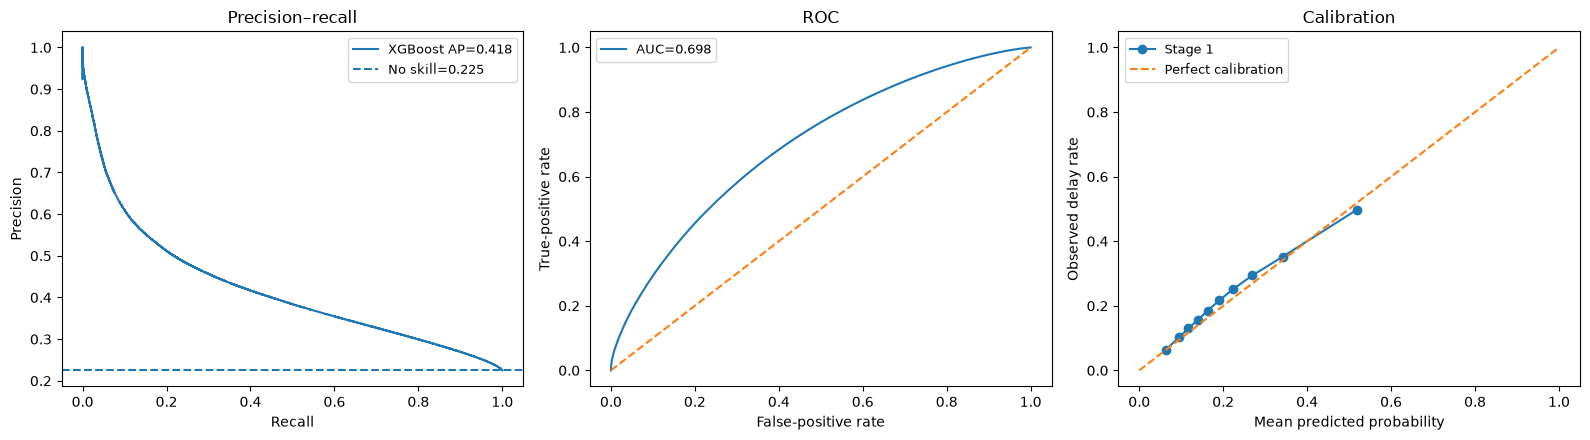

In [10]:
precision, recall, _ = precision_recall_curve(y_valid, p_valid)
fpr, tpr, _ = roc_curve(y_valid, p_valid)
frac_pos, mean_pred = calibration_curve(y_valid, p_valid, n_bins=10, strategy="quantile")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(recall, precision, label=f"XGBoost AP={metrics.loc['Stage 1 XGBoost', 'PR_AUC']:.3f}")
axes[0].axhline(y_valid.mean(), linestyle="--", label=f"No skill={y_valid.mean():.3f}")
axes[0].set(xlabel="Recall", ylabel="Precision", title="Precision–recall")
axes[0].legend(fontsize=9)

axes[1].plot(fpr, tpr, label=f"AUC={metrics.loc['Stage 1 XGBoost', 'ROC_AUC']:.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC")
axes[1].legend(fontsize=9)

axes[2].plot(mean_pred, frac_pos, marker="o", label="Stage 1")
axes[2].plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
axes[2].set(xlabel="Mean predicted probability", ylabel="Observed delay rate", title="Calibration")
axes[2].legend(fontsize=9)

plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_01_validation_curves.png", bbox_inches="tight")
plt.show()

### Stage 1 diagnostic plots — interpretation
 - **Precision–recall:** The curve stays well above the **22.5%** no-skill
   baseline. Precision is strongest for the highest-risk flights and declines
   gradually as recall increases, confirming useful ranking signal.
 - **ROC:** An AUC of **0.698** indicates moderate discrimination. The model
   separates delayed from non-delayed flights meaningfully, but many cases remain
   difficult to distinguish using information available at scheduled departure.
 - **Calibration:** Predicted probabilities track observed delay rates closely.
   The model slightly underpredicts risk in several middle-probability bins and
   slightly overpredicts the highest displayed bin, consistent with the low
   **ECE of 0.017**.

## 7. Diagnostic operating threshold

The hurdle model uses probabilities directly and does not require a threshold.
For a confusion matrix only, report the 2025 threshold that maximizes F1. This
is a development choice and must be frozen before final 2026 scoring.

In [11]:
pr_precision, pr_recall, thresholds = precision_recall_curve(y_valid, p_valid)
f1 = 2 * pr_precision[:-1] * pr_recall[:-1] / np.maximum(pr_precision[:-1] + pr_recall[:-1], 1e-12)
best_idx = int(np.nanargmax(f1))
best_threshold = float(thresholds[best_idx])


def threshold_metrics(threshold: float) -> dict[str, float | int]:
    pred = p_valid >= threshold
    tn, fp, fn, tp = confusion_matrix(y_valid, pred).ravel()
    return {
        "threshold": threshold,
        "precision": precision_score(y_valid, pred, zero_division=0),
        "recall": recall_score(y_valid, pred, zero_division=0),
        "specificity": tn / (tn + fp),
        "predicted_positive_rate": pred.mean(),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }


threshold_table = pd.DataFrame([
    threshold_metrics(t) for t in sorted(set([0.10, 0.20, 0.30, 0.40, 0.50, best_threshold]))
])
print(f"Diagnostic max-F1 threshold: {best_threshold:.3f}")
print(threshold_table.round(3).to_string(index=False))

Diagnostic max-F1 threshold: 0.198
 threshold  precision  recall  specificity  predicted_positive_rate      TP      FP      FN      TN
     0.100      0.256   0.940        0.206                    0.827 1458732 4244478   93421 1100380
     0.198      0.342   0.646        0.639                    0.425 1002861 1929145  549292 3415713
     0.200      0.344   0.640        0.645                    0.419  992831 1895404  559322 3449454
     0.300      0.425   0.376        0.853                    0.199  583574  788054  968579 4556804
     0.400      0.502   0.214        0.938                    0.096  331708  328729 1220445 5016129
     0.500      0.588   0.115        0.977                    0.044  179169  125527 1372984 5219331


The max-F1 threshold is 0.198.

At this threshold:
- Recall = 64.6%: captures about two thirds of delayed flights.
- Precision = 34.2%: about one in three flagged flights is actually delayed.
- Specificity = 63.9%: correctly leaves 63.9% of non-delayed flights unflagged.
- Predicted-positive rate = 42.5%: flags substantially more flights than the actual 22.5% delay prevalence.

Lower thresholds prioritize disruption capture but create many false alarms;
 higher thresholds improve precision but miss most delayed flights. The final
 operational threshold should therefore reflect the relative cost of missed
 delays and unnecessary alerts rather than relying automatically on maximum F1. For example,

 - Passenger warning system: favor recall; tolerate more false alarms
 - Airport intervention: limit alert volume; prioritize precision; maximize delayed-flight capture within the top 10% or 20% of flights

 No classification threshold is needed for the hurdle model itself: Stage 1
 probabilities should be multiplied directly by Stage 2 conditional-delay
 predictions.

## 8. Temporal stability within 2025

A useful Stage 1 model should beat the monthly prevalence baseline throughout
the year, not only in aggregate. Large changes in PR-AUC, Brier score or mean
prediction indicate drift or poor calibration in specific months.

 period  flights  actual_rate  mean_prediction  PR_AUC  ROC_AUC  Brier
2025-01   523167       0.1893           0.2411  0.3583   0.6744 0.1460
2025-02   497343       0.2090           0.1884  0.4359   0.7049 0.1471
2025-03   593741       0.1978           0.2085  0.3698   0.6923 0.1458
2025-04   578961       0.1983           0.1914  0.3810   0.6917 0.1453
2025-05   599192       0.2381           0.2641  0.4296   0.6935 0.1656
2025-06   601662       0.2852           0.2516  0.4986   0.7118 0.1812
2025-07   615731       0.2922           0.2947  0.4924   0.7032 0.1851
2025-08   595815       0.2283           0.2338  0.4248   0.7041 0.1587
2025-09   559481       0.1680           0.1508  0.3245   0.6890 0.1302
2025-10   602559       0.2045           0.1452  0.3756   0.6893 0.1544
2025-11   556244       0.2070           0.1499  0.4024   0.7014 0.1532
2025-12   573115       0.2692           0.2156  0.4878   0.7013 0.1783


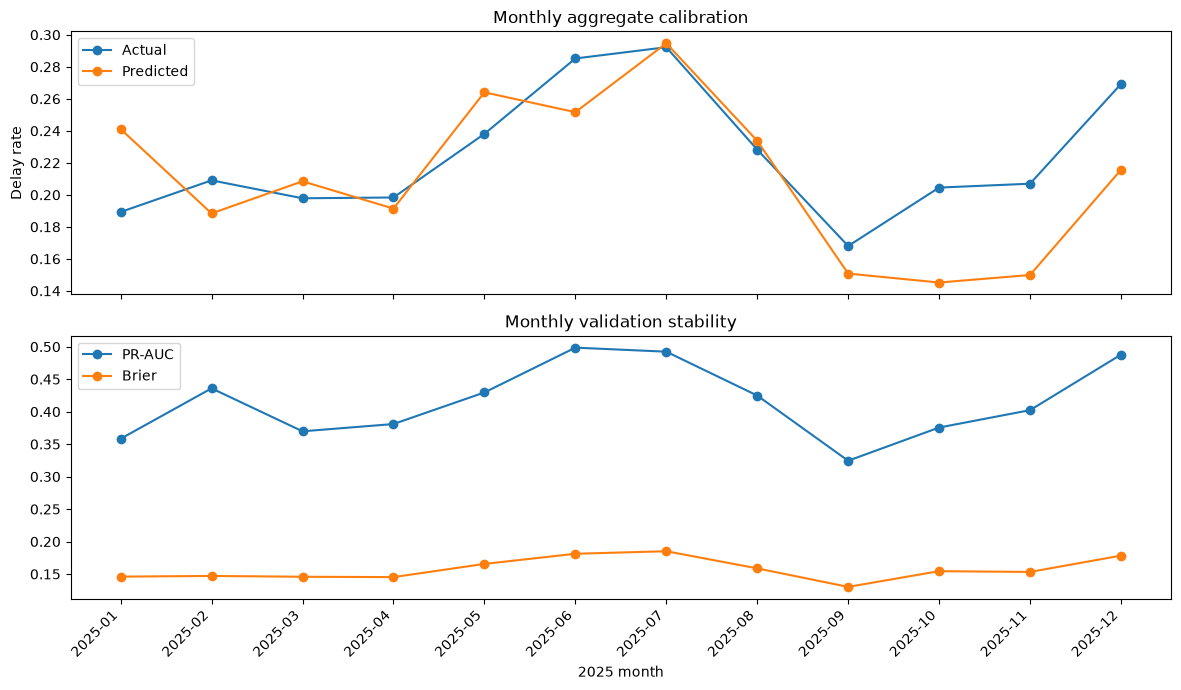

In [12]:
validation_results = valid_meta.reset_index(drop=True).assign(
    y_true=np.asarray(y_valid),
    p_delay=p_valid,
)
validation_results["period"] = pd.to_datetime(validation_results["FlightDate"]).dt.to_period("M").astype(str)

monthly = []
for period, group in validation_results.groupby("period", observed=True):
    monthly.append({
        "period": period,
        "flights": len(group),
        "actual_rate": group["y_true"].mean(),
        "mean_prediction": group["p_delay"].mean(),
        "PR_AUC": average_precision_score(group["y_true"], group["p_delay"]),
        "ROC_AUC": roc_auc_score(group["y_true"], group["p_delay"]),
        "Brier": brier_score_loss(group["y_true"], group["p_delay"]),
    })
monthly = pd.DataFrame(monthly)
print(monthly.round(4).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly["period"], monthly["actual_rate"], marker="o", label="Actual")
axes[0].plot(monthly["period"], monthly["mean_prediction"], marker="o", label="Predicted")
axes[0].set(ylabel="Delay rate", title="Monthly aggregate calibration")
axes[0].legend()
axes[1].plot(monthly["period"], monthly["PR_AUC"], marker="o", label="PR-AUC")
axes[1].plot(monthly["period"], monthly["Brier"], marker="o", label="Brier")
axes[1].set(xlabel="2025 month", title="Monthly validation stability")
axes[1].legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_01_monthly_validation.png", bbox_inches="tight")
plt.show()

 - Aggregate calibration is strong from February through September, with predicted
   and observed monthly delay rates generally close.
 - January is overpredicted by roughly **5 percentage points**.
 - The model materially underpredicts October–December, by about **5–6 percentage
   points** each month. This indicates late-2025 temporal drift in the baseline
   delay rate.
 - July is almost perfectly calibrated at the monthly level.
 - Ranking remains useful during the late-year underprediction: December has one
   of the highest PR-AUC values even though its average probability is too low.
   The model can therefore identify relatively risky flights while understating
   their absolute risk.

 period  actual_rate  mean_prediction  calibration_gap  pr_auc_lift  brier_skill
2025-01       0.1893           0.2411           0.0518       1.8930       0.0485
2025-02       0.2090           0.1884          -0.0207       2.0854       0.1106
2025-03       0.1978           0.2085           0.0106       1.8689       0.0812
2025-04       0.1983           0.1914          -0.0069       1.9207       0.0864
2025-05       0.2381           0.2641           0.0260       1.8044       0.0872
2025-06       0.2852           0.2516          -0.0336       1.7482       0.1112
2025-07       0.2922           0.2947           0.0025       1.6849       0.1050
2025-08       0.2283           0.2338           0.0055       1.8612       0.0989
2025-09       0.1680           0.1508          -0.0172       1.9310       0.0685
2025-10       0.2045           0.1452          -0.0593       1.8363       0.0509
2025-11       0.2070           0.1499          -0.0570       1.9442       0.0664
2025-12       0.2692        

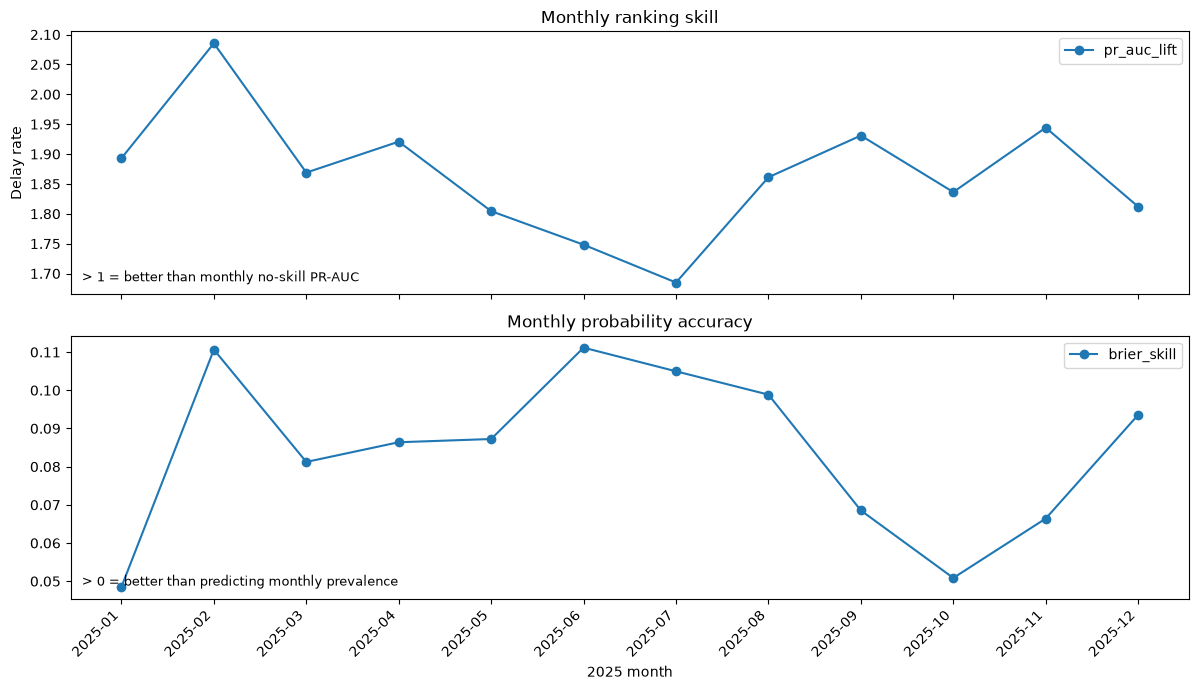

In [13]:
# Raw monthly PR-AUC partly changes with monthly delay prevalence. Check PR_AUC / prevalence.
# Brier score also depends on prevalence. A lower Brier score in a low-delay month does not 
# automatically mean better model performance. Evaluate with a month-specific prevalence baseline.

monthly["calibration_gap"] = (
    monthly["mean_prediction"] - monthly["actual_rate"]
)
monthly["pr_auc_lift"] = (
    monthly["PR_AUC"] / monthly["actual_rate"]
)
monthly["baseline_brier"] = (
    monthly["actual_rate"] * (1 - monthly["actual_rate"])
)
monthly["brier_skill"] = (
    1 - monthly["Brier"] / monthly["baseline_brier"]
)
print(
    monthly[
        [
            "period",
            "actual_rate",
            "mean_prediction",
            "calibration_gap",
            "pr_auc_lift",
            "brier_skill",
        ]
    ].round(4).to_string(index=False)
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(monthly["period"], monthly["pr_auc_lift"], marker="o", label="pr_auc_lift")
axes[0].set(ylabel="Delay rate", title="Monthly ranking skill")
axes[0].text(
    0.01, 0.05,
    "> 1 = better than monthly no-skill PR-AUC",
    transform=axes[0].transAxes,
    fontsize=9,
)
axes[0].legend()
axes[1].plot(monthly["period"], monthly["brier_skill"], marker="o", label="brier_skill")
axes[1].set(xlabel="2025 month", title="Monthly probability accuracy")
axes[1].text(
    0.01, 0.05,
    "> 0 = better than predicting monthly prevalence",
    transform=axes[1].transAxes,
    fontsize=9,
)
axes[1].legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_01_monthly_skill.png", bbox_inches="tight")
plt.show()

## 9. Gain importance and saved development artifacts

Gain importance is a model-debugging view, not the final interpretation. SHAP
and permutation importance are run after the Stage 1 specification is accepted.

In [14]:
importance = (
    pd.Series(
        model.get_booster().get_score(importance_type="gain"),
        name="gain",
    )
    .rename_axis("feature")
    .reset_index()
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)
importance["gain_share"] = importance["gain"] / importance["gain"].sum()
importance["cumulative_gain_share"] = importance["gain_share"].cumsum()

print(
    importance[
        ["feature", "gain", "gain_share", "cumulative_gain_share"]
    ].head(20).to_string(
        index=False,
        formatters={
            "gain": "{:,.1f}".format,
            "gain_share": "{:.1%}".format,
            "cumulative_gain_share": "{:.1%}".format,
        },
    )
)

               feature    gain gain_share cumulative_gain_share
  origin_frozen_precip 1,882.1      22.9%                 22.9%
   origin_thunderstorm 1,151.2      14.0%                 36.8%
        sched_dep_hour   690.1       8.4%                 45.2%
     dest_thunderstorm   653.6       7.9%                 53.1%
      origin_precip_3h   510.2       6.2%                 59.3%
     next_holiday_name   279.1       3.4%                 62.7%
                 Month   276.2       3.4%                 66.1%
  dest_flight_category   263.2       3.2%                 69.3%
    dest_frozen_precip   262.2       3.2%                 72.5%
origin_ifr_hours_past3   250.4       3.0%                 75.5%
     Reporting_Airline   207.7       2.5%                 78.0%
                Origin   168.9       2.1%                 80.1%
     prev_holiday_name   166.6       2.0%                 82.1%
                  Dest   157.3       1.9%                 84.0%
    origin_max_gust_3h   129.8       1.6

 - Importance is concentrated: the top **5 features explain 59.3%** of total gain,
   the top **10 explain 75.5%**, and the top **20 explain 92.7%**.
 - Weather is the dominant feature group. Frozen precipitation, thunderstorms,
   recent precipitation, IFR history, gusts, and visibility collectively provide
   most of the model's predictive separation.
 - `sched_dep_hour` contributes **8.4%**, confirming that delay risk changes
   strongly across the operating day.
 - Calendar features contribute meaningful signal, especially month and proximity
   to holidays.
 - Carrier, origin, and destination together contribute about **6.5%** directly,
   although their effects may also appear through interactions with weather,
   schedule, and demand features.

### 9.1 TreeSHAP global importance

Identify which features make the largest contributions to its 2025 validation predictions. Sampling keeps the computation practical without changing the fitted model.

In [15]:
SHAP_SAMPLE_N = 50_000
shap_sample = X_valid.sample(
    n=min(SHAP_SAMPLE_N, len(X_valid)),
    random_state=RANDOM_STATE,
).copy()

shap_dmatrix = DMatrix(shap_sample, enable_categorical=True)
shap_contrib = model.get_booster().predict(
    shap_dmatrix,
    pred_contribs=True,
    approx_contribs=False,
    validate_features=True,
)

if shap_contrib.shape[1] != len(FEATURES) + 1:
    raise AssertionError(
        "TreeSHAP output should contain one contribution per feature plus the bias term"
    )

shap_values = shap_contrib[:, :-1]
shap_base_values = shap_contrib[:, -1]

# TreeSHAP contributions should reconstruct the raw XGBoost margin.
raw_margin = model.get_booster().predict(
    shap_dmatrix,
    output_margin=True,
    validate_features=True,
)
max_additivity_error = float(
    np.max(np.abs(raw_margin - (shap_base_values + shap_values.sum(axis=1))))
)
print(f"SHAP sample rows: {len(shap_sample):,}")
print(f"Max TreeSHAP additivity error: {max_additivity_error:.3e}")

shap_importance = pd.DataFrame({
    "feature": FEATURES,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
})
shap_importance = shap_importance.sort_values(
    "mean_abs_shap", ascending=False
).reset_index(drop=True)
shap_importance["shap_share"] = (
    shap_importance["mean_abs_shap"] / shap_importance["mean_abs_shap"].sum()
)
shap_importance["cumulative_shap_share"] = shap_importance["shap_share"].cumsum()

print("\nTop TreeSHAP model drivers")
print(
    shap_importance.head(20).to_string(
        index=False,
        formatters={
            "mean_abs_shap": "{:.4f}".format,
            "shap_share": "{:.1%}".format,
            "cumulative_shap_share": "{:.1%}".format,
        },
    )
)

SHAP sample rows: 50,000
Max TreeSHAP additivity error: 4.053e-06

Top TreeSHAP model drivers
                      feature mean_abs_shap shap_share cumulative_shap_share
               sched_dep_hour        0.3896      20.9%                 20.9%
                       Origin        0.1377       7.4%                 28.3%
            Reporting_Airline        0.1334       7.1%                 35.4%
                         Dest        0.1307       7.0%                 42.4%
                        Month        0.1091       5.8%                 48.2%
            next_holiday_name        0.1039       5.6%                 53.8%
         dest_flight_category        0.0803       4.3%                 58.1%
                    DayOfWeek        0.0793       4.2%                 62.4%
                origin_temp_c        0.0759       4.1%                 66.4%
         days_to_next_holiday        0.0687       3.7%                 70.1%
             origin_precip_3h        0.0661       3.5%     

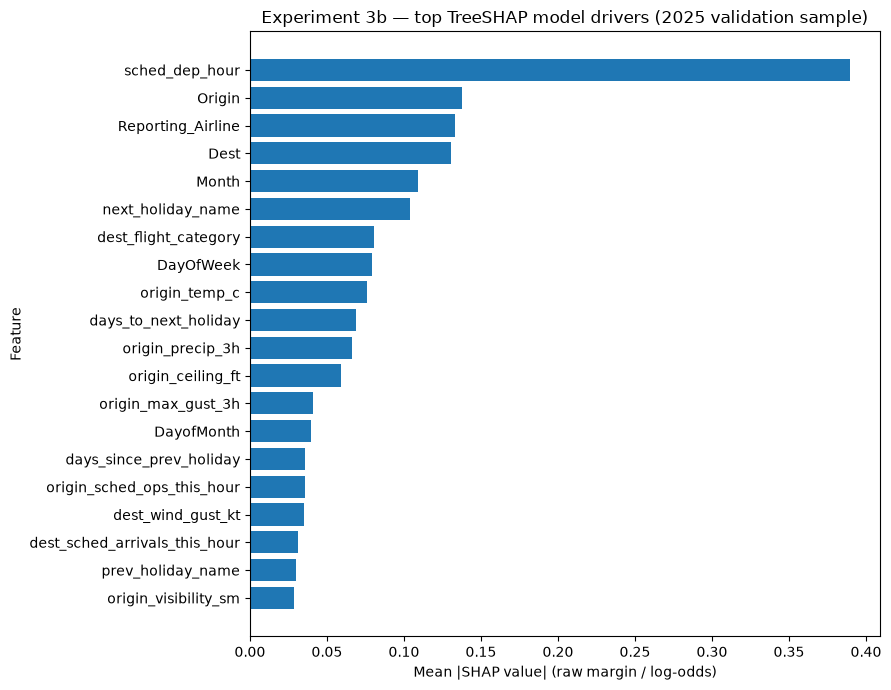

In [16]:
plot_shap = shap_importance.head(20).sort_values("mean_abs_shap")
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_shap["feature"], plot_shap["mean_abs_shap"])
ax.set(
    xlabel="Mean |SHAP value| (raw margin / log-odds)",
    ylabel="Feature",
    title="Experiment 3b — top TreeSHAP model drivers (2025 validation sample)",
)
plt.tight_layout()
fig.savefig(FIGURES / "03_stage1_03b_shap_importance.png", bbox_inches="tight")
plt.show()

## 10. Save comparable experiment artifacts

These files can be concatenated with other experiment outputs for cross-experiment evaluation later.

In [18]:
model_path = MODELS / f"{ROBUST_MODEL_NAME}.json"
metadata_path = MODELS / f"{ROBUST_MODEL_NAME}_metadata.json"
history_path = MODELS / f"{ROBUST_MODEL_NAME}_historical_state.joblib"
model.save_model(model_path)
metadata = {
    "train_year": TRAIN_YEAR,
    "validation_year": VALID_YEAR,
    "features": FEATURES,
    "categorical_features": CATEGORICAL,
    "best_iteration": int(model.best_iteration),
    "diagnostic_f1_threshold": best_threshold,
    "validation_metrics": metrics.loc["Stage 1 XGBoost"].to_dict(),
}
metadata_path.write_text(json.dumps(metadata, indent=2))
print(f"Saved model      : {model_path}")
print(f"Saved metadata   : {metadata_path}")

Saved model      : models/stage1_xgb_2024_to_2025_01.json
Saved metadata   : models/stage1_xgb_2024_to_2025_01_metadata.json


## Stage 1 Improvements

The main issue is time-specific underprediction.

- Add relative demand.
- Add smoothed 2024 historical priors.
- Compare depth 4, 6 and 8.
- Compare PR-AUC versus log-loss early stopping.
- Re-evaluate monthly calibration, especially October–December.
